In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
from matplotlib import font_manager
import lightgbm as lgb
import warnings
import math
import os
import re
import json
import numpy as np


from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient7.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [25]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [26]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [27]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [28]:
def XGBoost_train(X_train, y_train, X_val, y_val, key):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 200, step=10),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'random_state': 42,
            # 'use_label_encoder': False,
            'eval_metric': ['auc', 'logloss']
            # 'scale_pos_weight':
        }
        

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
        evals_result = model.evals_result()

        train_logloss = evals_result['validation_0']['logloss']
        val_logloss = evals_result['validation_1']['logloss']

        train_auc = evals_result['validation_0']['auc']
        val_auc = evals_result['validation_1']['auc']
        
        context = ""

        for key1, item1 in params.items():
            if key1 == 'use_label_encoder' or key1 == 'eval_metric':
                context = f"{context}{key1}:{item1}\n"
            else:
                # print(item1)
                context = f"{context}{key1}:{item1:.3f}\n"

        best_auc = 0
        for i in range(len(val_auc)):
            if val_auc[i] > best_auc:
                best_auc = val_auc[i]
                params['n_estimators'] = i

        # # 绘制损失曲线和AUC的变化
        # plt.figure(figsize=(8, 5))
        # plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
        # plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
        # plt.xlabel('轮数')
        # plt.ylabel('损失')
        # plt.title(f'{key}损失曲线（拟合情况）')
        # plt.text(len(train_logloss) - len(train_logloss)/10, train_logloss[-1]+0.02, f"AUC:{best_auc:.2f}", fontsize=12)
        # plt.text(len(train_logloss)/2, train_logloss[1]-(train_logloss[1]-train_logloss[-1])*0.35, f"param:{context}", fontsize=9)
        # plt.legend()
        # plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/Train/Loss/{key}损失情况{trial.number}.png", dpi=300, bbox_inches='tight')  # 保存为PNG
        

        # plt.figure(figsize=(8, 5))
        # plt.plot(range(1, len(train_auc) + 1), train_auc, label=f'Train AUC: {train_auc[-1]:.4f}')
        # plt.plot(range(1, len(val_auc) + 1), val_auc, label=f'Validation AUC: {best_auc:.4f}')
        # plt.xlabel('轮数')
        # plt.ylabel('AUC')
        # plt.title(f'{key}AUC变化情况')
        # plt.grid(True, alpha=0.3)
        # plt.text(len(train_auc)/2, train_auc[1]-(train_auc[1]-train_auc[-1])*0.35, f"param:{context}", fontsize=9)
        # plt.legend()
        # plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/Train/AUC/{key}AUC变化{trial.number}.png", dpi=300, bbox_inches='tight')  # 保存为PNG

        return 1.0 - best_auc

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    best_params['random_state'] = 42

    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_train, y_train)

    return [final_model,best_trial.params,best_params]



In [29]:
# 构建处理空值的Pipeline
def create_pipeline(X_train, y_train):
    # 创建完整的模型管道
    model_pipeline = Pipeline(steps=[
        # ('preprocessor', preprocessor),
        ('imputer', KNNImputer(n_neighbors=5)),  # 使用KNN填充数值型空值
        # ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    print("预处理管道构建完成")

    # 定义参数网格
    param_grid = {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }

    # 创建网格搜索对象
    print("开始超参数优化...")
    grid_search = GridSearchCV(
        model_pipeline, 
        param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1, 
        verbose=1
    )

    # 训练模型
    grid_search.fit(X_train, y_train)

    # 输出最佳结果
    print("\n优化完成!")
    print(f"最佳参数: {grid_search.best_params_}")
    print(f"最佳交叉验证AUC: {grid_search.best_score_:.4f}")

    # 获取最佳模型
    final_model = grid_search.best_estimator_
    return final_model
    

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name, key):
    # y_pred = model.predict(X)
    if isinstance(model, np.ndarray):
        y_pred_proba = model
    else:
        y_pred_proba = model.predict_proba(X)[:, 1]

    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1
            
    if dataset_name != '挑选':
        print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    # if dataset_name == '测试':
    #     predict = [[], []]
    #     y = list(y)
    #     for i in range(len(y)):
    #         if y[i] == 0:
    #             predict[0].append(y_pred_proba[i])
    #         if y[i] == 1:
    #             predict[1].append(y_pred_proba[i])
    #     group = key.split('vs')
    #     plt.boxplot(predict)
    #     plt.xticks([1, 2], [group[0], group[1]])
    #     plt.title(key)
    #     plt.ylabel("可能性")
    #     plt.show()

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)

    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

    # 评估训练集、验证集和测试集
    # train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
    # val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
    # test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

    # 可选：保存最佳模型
    # import joblib
    # joblib.dump(final_model, 'best_lgb_model.pkl')
    # print("\n最佳模型已保存为 'best_lgb_model.pkl'")

    # 可选：绘制特征重要性
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(10, 8))
    # lgb.plot_importance(final_model, max_num_features=15)
    # plt.title('Feature Importance')
    # plt.tight_layout()
    # plt.show()



In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LR+XGBoost1/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LR_XGBoost1 ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR_XGBoost1/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_XGBoost1_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LR_XGBoost1_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LR_XGBoost1_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LR_XGBoost1_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LR_XGBoost1_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LR_XGBoost1_Dataset{current_dataset}'][model] = data_to_append
    print(existing_data)
    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [32]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):
    # ---------------- SHAP 分析 -----------------
    explainer = shap.TreeExplainer(final_model, X_train)
    shap_values = explainer.shap_values(X_test)
    shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    # print(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png")
    plt.show()

    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_matrix, X_test, show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/XGBoost/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

In [33]:

# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data/filtered_patient8.csv'

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# print(filtered_df['血_乙型肝炎病毒核心抗体.IgM_定量'])

[I 2025-10-17 17:07:03,572] A new study created in memory with name: no-name-0cc58970-656c-4459-a69d-bbb1a4379d34


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.230174:   1%|          | 1/100 [00:00<00:26,  3.80it/s]

[I 2025-10-17 17:07:03,839] Trial 0 finished with value: 0.23017408123791105 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.23017408123791105.


...

[I 2025-10-17 17:07:52,901] Trial 97 finished with value: 0.1982591876208898 and parameters: {'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.010478925980538479, 'subsample': 0.6004371848084129, 'colsample_bytree': 0.8030532092762681, 'reg_alpha': 0.0015806720017970282, 'reg_lambda': 1.6898170991845727e-05, 'min_child_weight': 5, 'gamma': 4.87713642966029}. Best is trial 12 with value: 0.14845261121856868.


Best trial: 12. Best value: 0.148453:  99%|█████████▉| 99/100 [00:50<00:00,  1.54it/s]

[I 2025-10-17 17:07:53,798] Trial 98 finished with value: 0.18423597678916825 and parameters: {'n_estimators': 180, 'max_depth': 8, 'learning_rate': 0.012878233484365066, 'subsample': 0.6774582349567981, 'colsample_bytree': 0.8366780021545778, 'reg_alpha': 0.2944635991976836, 'reg_lambda': 0.00021313471154903684, 'min_child_weight': 3, 'gamma': 3.99256740809198}. Best is trial 12 with value: 0.14845261121856868.


Best trial: 12. Best value: 0.148453: 100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


[I 2025-10-17 17:07:54,408] Trial 99 finished with value: 0.21953578336557056 and parameters: {'n_estimators': 170, 'max_depth': 5, 'learning_rate': 0.004879501255701733, 'subsample': 0.9778517264500054, 'colsample_bytree': 0.6080907062003268, 'reg_alpha': 0.006646395660742173, 'reg_lambda': 0.0006990429610615301, 'min_child_weight': 5, 'gamma': 4.7339797185788965}. Best is trial 12 with value: 0.14845261121856868.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8515
  Best params: 
    n_estimators: 190
    max_depth: 10
    learning_rate: 0.0054681168313384255
    subsample: 0.602822975090678
    colsample_bytree: 0.8027936026422099
    reg_alpha: 1.5155324681197761e-05
    reg_lambda: 0.0007187551363037001
    min_child_weight: 3
    gamma: 4.960637251317072

使用最佳参数训练最终模型...
最佳阈值: 0.35，测试集最大auc: 0.7331

验证 集评估结果:
Accuracy: 0.7681
Precision: 0.6364
Recall: 0.6364
F1-Score: 0.6364
AUC: 0.7892
最佳阈值: 0.40，测试集最大auc: 0.7290

测试 集评估结果:
Accuracy: 0.8000
Precision: 0.8000
Re

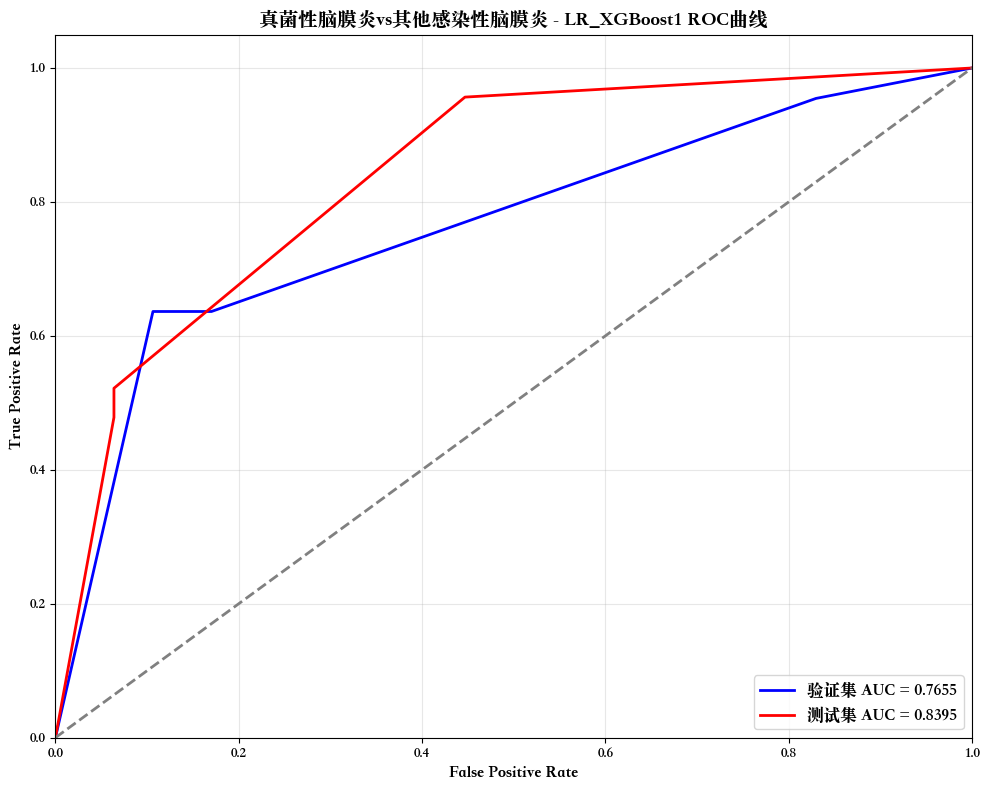

{'LR_XGBoost1_Dataset2': {'阴性组vs其他': {'val_accuracy': 0.9272, 'val_precision': 0.7188, 'val_recall': 0.92, 'val_f1': 0.807, 'roc_auc_val': 0.9594, 'test_accuracy': 0.9013, 'test_precision': 0.6389, 'test_recall': 0.92, 'test_f1': 0.7541, 'roc_auc_test': 0.9394}, '感染性脑膜炎v非感染组': {'val_accuracy': 0.9213, 'val_precision': 0.9538, 'val_recall': 0.8986, 'val_f1': 0.9254, 'roc_auc_val': 0.9445, 'test_accuracy': 0.874, 'test_precision': 0.8841, 'test_recall': 0.8841, 'test_f1': 0.8841, 'roc_auc_test': 0.8983}, '细菌性脑膜炎vs其他感染性脑膜炎': {'val_accuracy': 0.8261, 'val_precision': 0.5238, 'val_recall': 0.8462, 'val_f1': 0.6471, 'roc_auc_val': 0.8688, 'test_accuracy': 0.8696, 'test_precision': 0.6429, 'test_recall': 0.6923, 'test_f1': 0.6667, 'roc_auc_test': 0.8468}, '病毒性脑膜炎vs其他感染性脑膜炎': {'val_accuracy': 0.8088, 'val_precision': 0.625, 'val_recall': 0.9524, 'val_f1': 0.7547, 'roc_auc_val': 0.8723, 'test_accuracy': 0.8, 'test_precision': 0.6538, 'test_recall': 0.7727, 'test_f1': 0.7083, 'roc_auc_test': 0.8

In [ ]:


screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)


def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列
    selected_df = delete_same_col(selected_df)


    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]
    
    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # X_1 = delete_same_col(X_1)
    # X_2 = delete_same_col(X_2)

    # print(X_1.columns)
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到XGBoost最优模型
    XGBoost_result = XGBoost_train(X_train, y_train, X_val, y_val, key)
    XGBoost_final_model = XGBoost_result[0]
    # 评估验证集和测试集
    XGBoost_val_results = evaluate_model(XGBoost_final_model, X_val, y_val, "验证", key)
    XGBoost_test_results = evaluate_model(XGBoost_final_model, X_test, y_test, "测试", key)    
    
    # 得到LR最优模型
    LR_final_model = create_pipeline(X_train, y_train)

    # 评估验证集和测试集
    LR_val_results = evaluate_model(LR_final_model, X_val, y_val, "验证", key)
    LR_test_results = evaluate_model(LR_final_model, X_test, y_test, "测试", key)    

    xgb_pred = XGBoost_test_results['y_pred']
    lr_pred = LR_test_results['y_pred']
    w = [0.6,0.65,0.7,0.75,0.8,0.85,0.9]
    best_auc = 0
    best_w = 0
    for i in w:
        final_pred = i * xgb_pred + (1 - i) * lr_pred
        # print(final_pred)
        final_results = evaluate_model(final_pred, X_test, y_test, "挑选", key)    
        if final_results['auc'] > best_auc:
            best_auc = final_results['auc']
            best_w = i

    final_pred_val = best_w * XGBoost_val_results['y_pred'] + (1 - best_w) * LR_val_results['y_pred']
    final_pred_test = best_w * xgb_pred + (1 - best_w) * lr_pred
    final_val_results = evaluate_model(final_pred_val, X_val, y_val, "验证", key)    
    final_test_results = evaluate_model(final_pred_test, X_test, y_test, "测试", key)    
    best_auc = final_results['auc']
    print(f'最优权重为：{best_w}，最优结果为{best_auc}')


    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, final_val_results, final_test_results, key, current_dataset)

    # # 绘制shap图
    # draw_shap(final_model, X_train, X_test, current_dataset, key)
    return LR_test_results

    
if extract_integers(data_path)[-1] == 2:
    # print(filtered_df.columns)
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎v非感染组': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
finish = 0
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

    # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)

     
        

In [ ]:
'''
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# filtered_df = filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']]
screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

item = []
for key, item1 in screen_data.items():
    item = item1
print(item)

selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

# 选择特征 将数据正例和反例平均分配
filter_1 = selected_df[selected_df["分组"].isin(item[1])]
filter_2 = selected_df[selected_df["分组"].isin(item[2])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]
# print(X_1.columns)
# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'].isin(item[1])).astype(int) 


# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

'''


'\nfiltered_df = label_encoding(filtered_df, data_path)\n# 对 DataFrame 的列名进行清洗\nfiltered_df.columns = clean_feature_names_simple(filtered_df.columns)\n\n# 数据预处理：将 \'gender\' 列转换为数值型\nfiltered_df[\'gender\'] = filtered_df[\'gender\'].map({\'女\': 0, \'男\': 1})\n# filtered_df = filtered_df[[\'脑脊液_多个核细胞百分比_定量\',\'血_C反应蛋白_定量\',\'脑脊液_有核细胞计数_定量\',\'血_抗凝血酶III_定量\',\'血_血小板分布宽度_定量\',\'血_单核细胞计数_定量\', \'血_细胞.CD3+CD8+百分比_定量\',\'分组\', \'组名\']]\nscreen_data = {\n    \'阴性组vs其他\':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],\n    # \'感染性脑膜炎v非感染组\': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],\n    # \'细菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [1],  [2,3,4]],\n    # \'病毒性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [2], [1,3,4]],\n    # \'结核性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [3], [1,2,4]],\n    # \'真菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [4], [1,2,3]],\n    # \'肿瘤性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],\n    # \'自身免疫性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],\n    # \'病毒性脑膜炎vs病毒性脑炎\': [[2,8], [2], [8]]\n    }\n\nitem = []\nfor key, item1 in 

In [ ]:
'''


# params = {
#     'n_estimators': 1000,
#     'max_depth': 10,
#     'learning_rate': 0.0010217263561859077,
#     'subsample': 0.765745015802337,
#     'colsample_bytree': 0.7206332428817546,
#     'reg_alpha': 7.571565639799907e-07,
#     'reg_lambda':  0.007669065286362127,
#     'min_child_weight': 1,
#     'gamma': 0.028423560884985488,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }
result_para['n_estimators'] = 140
# result_para['use_label_encoder'] = False
# result_para['eval_metric'] = 'logloss'
# result_para['random_state'] = 42
# params = {
#     'n_estimators': 500,
#     'max_depth': 3,
#     'learning_rate': 0.014423244028784152,
#     'subsample': 0.9003002169351246,
#     'colsample_bytree': 0.8158764226043772,
#     'reg_alpha': 0.043594962064358575,
#     'reg_lambda':  0.4046273356274994,
#     'min_child_weight': 2,
#     'gamma': 0.24895493093075793,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }


model = xgb.XGBClassifier(**result_para)
# evals_result = {}
# 训练模型
model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
    # eval_metric="logloss",
    verbose=False,
    # evals_result=evals_result
)
evals_result = model.evals_result()

train_logloss = evals_result['validation_0']['logloss']
val_logloss = evals_result['validation_1']['logloss']

val_results = evaluate_model(model, X_val, y_val, "验证", "阴性组")   
test_results = evaluate_model(model, X_test, y_test, "测试", "阴性组")   
 
# print(test_results['auc'])
# 绘制曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
plt.legend()
plt.show()

'''